# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10793 entries, 8 to 11374
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   CashAndCashEquivalents                10793 non-null  float64       
 1   CurrentDebt                           10793 non-null  float64       
 2   LongTermDebt                          10793 non-null  float64       
 3   TotalDebt                             10793 non-null  float64       
 4   StockholdersEquity                    10793 non-null  float64       
 5   TotalAssets                           10793 non-null  float64       
 6   CurrentAssets                         10793 non-null  float64       
 7   CurrentLiabilities                    10793 non-null  float64       
 8   OperatingCashFlow_TTM                 10793 non-null  float64       
 9   InvestingCashFlow_TTM                 10793 non-null  float64       
 10  Fin

## Feature Engineering

In [3]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [4]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Incluir las variables que tengan baja importancia para reducir el ruido (ej: importance < 0.01)
variables_no_significativas = [

]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Posibles labels:
    # 1) Ratios de valuación
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda',    
    # 2) Variables de tamaño (si se usan como label, quitar predictores RelativeAssets y RelativeRevenue para evitar Data Leakage)
    'MarketCap_Log1p',
    'EnterpriseValue_Log1p',

    # Precios (no usar como labels, no tiene sentido predecir precios crudos teniendo multiples tickers)
    'Open',
    'Close',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource',
    'AverageDailyVolume_Lag1'
    ]

# Se define la variable objetivo y las variables predictoras
label = 'EnterpriseToEbitda'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.1899


In [5]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.1581 ± 0.0789


In [6]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
19,num__EBITDA_TTM_Acceleration,0.292706
6,num__NetDebtToEbitda,0.200050
10,num__EBITDA_TTM_YoY,0.154050
7,num__FcfToEbitda,0.124202
31,cat__Industry,0.058755
11,num__EBITDA_TTM_QoQ,0.024805
12,num__FreeCashFlow_TTM_YoY,0.021110
30,cat__Sector,0.015376
3,num__ReturnOnEquity,0.010838
28,num__DebtToEquity_Log1p,0.009948


In [7]:
feature_importance_df.tail(6)

,feature,importance
18,num__TotalRevenue_TTM_Acceleration,0.002848
27,num__CapExToRevenue_Log1p,0.002653
16,num__AverageDailyVolume_Lag1_YoY,0.002166
24,num__MarketCovariance_Lag1,0.001648
9,num__TotalRevenue_TTM_QoQ,0.001345
17,num__AverageDailyVolume_Lag1_QoQ,0.001228


In [8]:
# Visualizar distribución de features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,10793.0,15.047901,19.627335,0.000000,0.000000,7.000000,24.000000,69.000000
OperatingMargins,10793.0,0.146288,0.064969,-0.068613,0.099182,0.138506,0.181641,0.430169
ProfitMargins,10793.0,0.100630,0.053209,-0.127108,0.063900,0.093131,0.126352,0.314853
ReturnOnEquity,10793.0,0.281890,0.227207,-0.638058,0.132685,0.210838,0.347252,0.991215
ReturnOnAssets,10793.0,0.082925,0.059855,-0.099573,0.042916,0.066911,0.103936,0.287166
CurrentRatio,10793.0,1.547520,0.561287,0.317722,1.171285,1.433775,1.797223,3.675249
NetDebtToEbitda,10793.0,4.640009,4.714965,-11.066286,1.651870,3.175002,5.888246,18.627080
FcfToEbitda,10793.0,0.881974,0.639522,-1.317712,0.511913,0.760508,1.098315,2.860574
TotalRevenue_TTM_YoY,10793.0,0.199733,0.606820,-0.908645,-0.187919,0.072743,0.413050,2.218169
TotalRevenue_TTM_QoQ,10793.0,0.025838,0.148989,-0.453947,-0.047616,0.014600,0.084759,0.483717


## Aplicación del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [9]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train, X_test, y_train, y_test = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Se calculan los residuos y el Cluster: PositiveBias / NegativeBias según el signo de los residuos
resultados_agrupados = procesar_resultados_prediccion(
    y_test=y_test, 
    y_pred=y_pred, 
    tickers=tickers_test
)

# Visualizar los resultados de la predicción
visualizar_resultados_predicciones(resultados_agrupados)


Estadísticas por cluster (a nivel de Ticker):
Sesgos positivos: 340 tickers, residuo medio global: 6.8509
Sesgos negativos: 141 tickers, residuo medio global: -7.5131


In [10]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker  Predicted  Observed  Residuals      Cluster  PercentError
   FMC 165.559774 13.682657 151.877117 PositiveBias   1109.997256
   MTH  42.567552 12.693663  29.873889 PositiveBias    235.344900
   RHI  67.560377 40.038847  27.521530 PositiveBias     68.737068
  LYFT  35.213102  7.957352  27.255750 PositiveBias    342.522860
  NVDA  44.336418 21.059203  23.277215 PositiveBias    110.532270


In [11]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,AverageDailyVolume_Lag1_Acceleration,QuarterlyReturn_Lag1,MarketCovariance_Lag1,RelativeAssets,RelativeRevenue,CapExToRevenue_Log1p,DebtToEquity_Log1p,QuarterlyVariance_Lag1_Log1p,MarketCap_Log1p,EnterpriseValue_Log1p
0,FMC,165.559774,13.682657,151.877117,PositiveBias,1109.997256,497.700,52.9720,2770.600,3425.000,...,0.379797,-0.019108,0.024607,0.000876,0.001077,0.014015,0.888037,1.172205,7.772506,8.697632
1,MTH,42.567552,12.693663,29.873889,PositiveBias,235.344900,766.632,60.7840,4428.746,5081.157,...,3.138738,-0.205489,0.025466,0.001015,0.002460,0.086337,0.885469,0.424952,9.658640,9.994538
2,RHI,67.560377,40.038847,27.521530,PositiveBias,68.737068,464.435,890.8765,7065.000,3009.400,...,-0.296170,-0.242275,-0.029263,0.000277,0.001157,0.035201,0.722282,0.489315,9.488783,9.657888
3,LYFT,35.213102,7.957352,27.255750,PositiveBias,342.522860,1034.869,248.0000,1178.804,1899.782,...,0.553073,-0.448153,-0.075241,0.000817,0.000939,0.021610,0.704961,1.689829,8.582586,9.156094
4,NVDA,44.336418,21.059203,23.277215,PositiveBias,110.532270,2260.000,240.3070,6675.000,7121.000,...,-2.024835,0.058660,-0.011106,0.002893,0.002117,0.094414,0.702351,0.385306,10.287493,10.337656


## Explicabilidad del Modelo (SHAP)

In [12]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'GOOG'

--- Explicación de la predicción para: GOOG ---


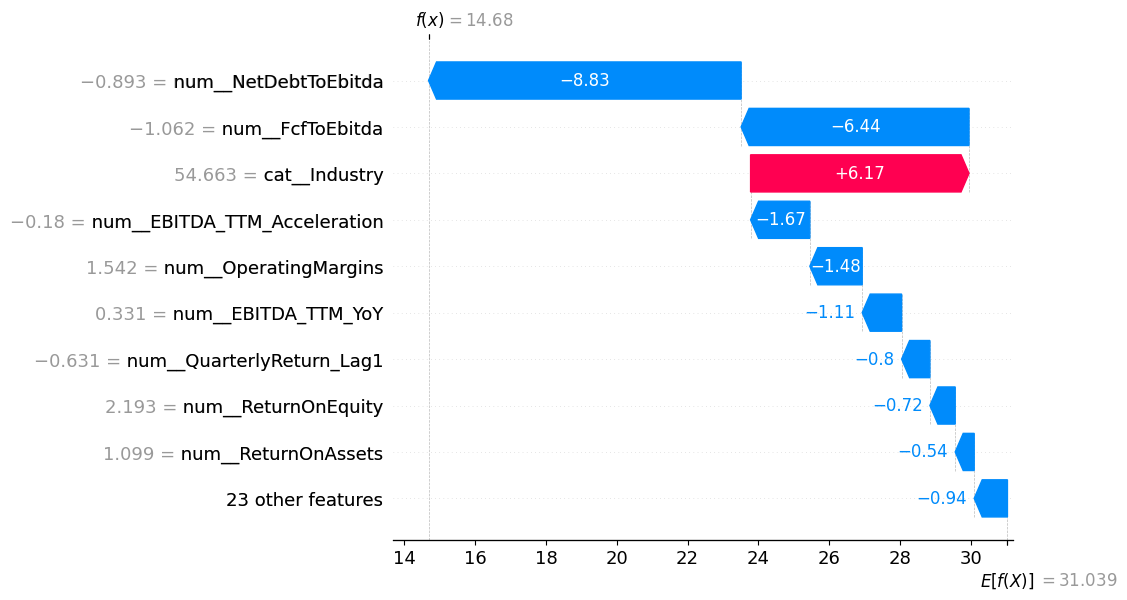

In [13]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [14]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)